# QF 627 Programming and Computational Finance 
## `Py`Day Week `5` | Problem-Sets for Exercise `4` | `RE`view

> "Hi Team! 👋

> The current notebook contains 10 questions that help you review our course content.

> Each question asks you to answer with specific results. Some questions are the `reverse-engineering-type` questions as I have asked in exercise problem set 3. Other questions require direct answers (because, given the nature of the question, reverse-engineering is not feasible).

> These questions won’t be difficult to solve—and answering them will strengthen your understanding of the learning materials. Importantly, the pathway to each answer has been given in lecture scripts, in-class lessons, answers to discussion board questions, and assigned readings. 

> First try to answer to the questions without setting any time constraints. Then, remove all your answers and try to answer again within a 90-minute time limit (and you may refer to lecture notes and review scripts while you are answering). This kind of timed task will improve your performance and prepare you well for the assessment down the line. Once you complete this, submit your script via eLearn.

> Enjoy!"

##### First, let's do some quick exercise with stock prices data.

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

from pandas_datareader import data as pdr

import datetime as dt
import yfinance as yf

/Users/sroh/miniforge3/envs/rohenv/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


> Let's set some print option.

In [2]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

### <font color = red> Question 1</font>. Please import historical stock data from the web on the following financial instruments, and create the following DataFrame that contains adjusted closing prices. 

### Here, the timeframe should be set between the 13th of October 2014 through the 13th of September 2022 (nine years of data).

- `WMT` Stock of Walmart
- `IBM` Stock of IBM

In [4]:
%whos

Variable   Type      Data/Info
------------------------------
dt         module    <module 'datetime' from '<...>b/python3.9/datetime.py'>
mpl        module    <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np         module    <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd         module    <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
pdr        module    <module 'pandas_datareade<...>ndas_datareader/data.py'>
plt        module    <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
yf         module    <module 'yfinance' from '<...>es/yfinance/__init__.py'>


In [6]:
# set dates 

start = dt.datetime(2014, 10, 13)
end = dt.datetime(2022, 9, 14)

# extract walmart (wmt)

walmart =\
(
    yf
    .download("WMT",
             start, 
             end)
)

walmart["Tickers"] = "WMT"

[*********************100%%**********************]  1 of 1 completed


In [7]:
walmart

,Open,High,Low,Close,Adj Close,Volume,Tickers
Date,,,,,,,
2014-10-13,26.010000,26.193333,25.816668,25.853333,21.094616,24603600,WMT
2014-10-14,25.943333,26.209999,25.889999,25.993334,21.208841,23703300,WMT
2014-10-15,25.860001,25.896667,24.786667,25.066668,20.452742,63173100,WMT
2014-10-16,24.410000,24.690001,24.203333,24.606667,20.077412,43039800,WMT
2014-10-17,24.726667,24.833332,24.343332,24.700001,20.153570,34386900,WMT
...,...,...,...,...,...,...,...
2022-09-07,44.353333,45.323334,44.246666,45.246666,43.970848,17058900,WMT
2022-09-08,45.133331,45.623333,44.959999,45.476665,44.194363,16956000,WMT
2022-09-09,45.433334,45.833332,45.376667,45.613335,44.327183,16140600,WMT


In [8]:
ibm =\
(
    yf
    .download("IBM",
              start,
              end)
)

ibm["Tickers"] = "IBM"

ibm

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,Tickers
Date,,,,,,,
2014-10-13,177.332703,178.441681,175.353729,175.449326,114.104874,3762148,IBM
2014-10-14,176.759079,177.552582,175.516251,175.717010,114.278976,4105236,IBM
2014-10-15,174.435944,175.707458,170.889099,173.757172,113.004356,7213007,IBM
2014-10-16,171.892929,173.499039,170.831741,171.931168,111.816803,5835216,IBM
2014-10-17,173.269592,174.799240,172.294449,174.043976,113.190910,4550309,IBM
...,...,...,...,...,...,...,...
2022-09-07,126.690002,127.870003,126.279999,127.709999,116.953560,2401500,IBM
2022-09-08,127.199997,128.539993,126.589996,128.470001,117.649544,2964600,IBM
2022-09-09,128.899994,129.490005,128.059998,129.190002,118.308891,3291900,IBM


In [10]:
concat_DF_for_practice =\
(
    pd
    .concat([ibm,
             walmart]
           )
    .reset_index()
    
)

In [12]:
df =\
(
    concat_DF_for_practice
    .pivot(index = "Date",
           columns = "Tickers",
           values = "Adj Close")
)

In [13]:
df

Tickers,IBM,WMT
Date,,
2014-10-13,114.104874,21.094616
2014-10-14,114.278976,21.208841
2014-10-15,113.004356,20.452742
2014-10-16,111.816803,20.077412
2014-10-17,113.190910,20.153570
...,...,...
2022-09-07,116.953560,43.970848
2022-09-08,117.649544,44.194363
2022-09-09,118.308891,44.327183


### <font color = red> Question 2</font>. Please run a simple moving average crossover strategy for `IBM`.

### The two moving windows are 20 and 60 days.

### Please show your positions with a plot.

In [14]:
df_ibm =\
(
    df[["IBM"]]
)

# short-term SMA = 20 days
# long-term SMA = 60 days

# SSMA

df_ibm["SMA_20"] =\
(
    df_ibm
    ["IBM"]
    .rolling(window = 20)
    .mean()
)

# LSMA

df_ibm["SMA_60"] =\
(
    df_ibm
    ["IBM"]
    .rolling(window = 60)
    .mean()
)

In [15]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
concat_DF_for_practice   DataFrame               Date        Op<...>\n[3988 rows x 8 columns]
df                       DataFrame    Tickers            IBM   <...>\n[1994 rows x 2 columns]
df_ibm                   DataFrame    Tickers            IBM   <...>\n[1994 rows x 3 columns]
dt                       module       <module 'datetime' from '<...>b/python3.9/datetime.py'>
end                      datetime     2022-09-14 00:00:00
ibm                      DataFrame                      Open   <...>\n[1994 rows x 7 columns]
mpl                      module       <module 'matplotlib' from<...>/matplotlib/__init__.py'>
np                       module       <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd                       module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
pdr                      module       <module 'pandas_datareade<...>ndas_datareader/data.py'>


In [16]:
# Set positions

df_ibm["positions"] =\
(
    np
    .where(df_ibm["SMA_20"] > df_ibm["SMA_60"],
           1, -1)
)

df_ibm=\
(
    df_ibm
    .dropna() 
)

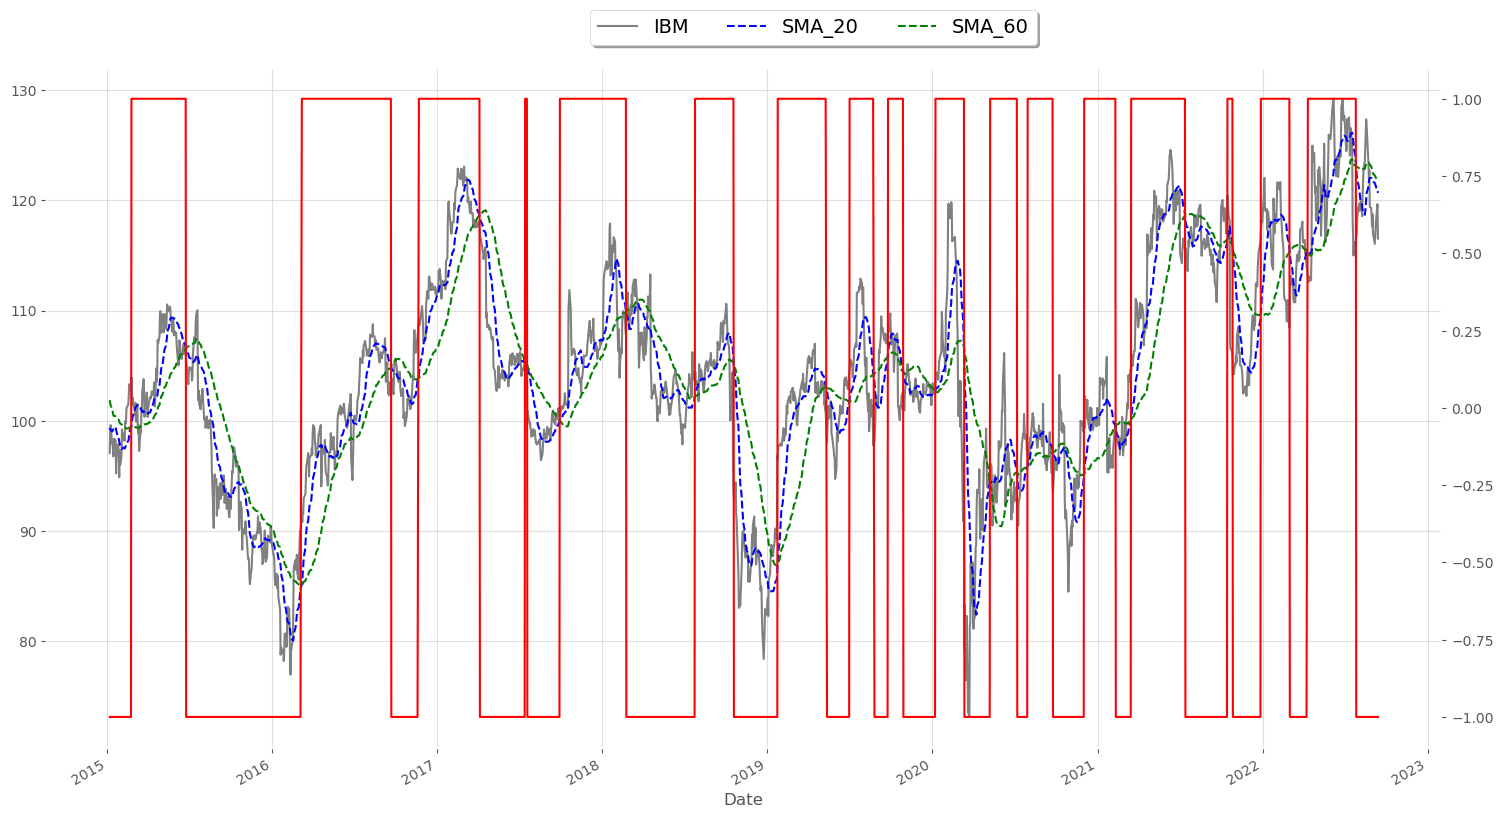

In [18]:
ax =\
(
    df_ibm
    [["IBM", "SMA_20", "SMA_60", "positions"]]
    .plot(secondary_y = "positions",
          color = ["grey", "blue", "green", "red"],
          style = ["-"   , "--"  , "--"   , "-"  ],
          figsize = [18, 10]
          )
)

(
    ax
    .legend(loc = "upper center",
            shadow = True,
            ncol = 4,
            bbox_to_anchor = (0.55, 1.10),
            fancybox = True
           )
)

### <font color = red> Question 3</font>. Based on your lines of codes that lead to answer 2 above, compare the returns to see if the strategy leads to a win over the passive benchmark investment.

In [22]:
df_ibm["RETURNS"] =\
(
    np
    .log(df_ibm["IBM"] 
         /
         df_ibm["IBM"].shift(1)
        )
)

In [21]:
df_ibm.columns

Index(['IBM', 'SMA_20', 'SMA_60', 'positions', 'returns'], dtype='object', name='Tickers')

In [23]:
df_ibm["STRATEGY"] =\
(
    df_ibm["positions"]
    .shift(1)
    *
    df_ibm["RETURNS"]
)

<Axes: xlabel='Date'>

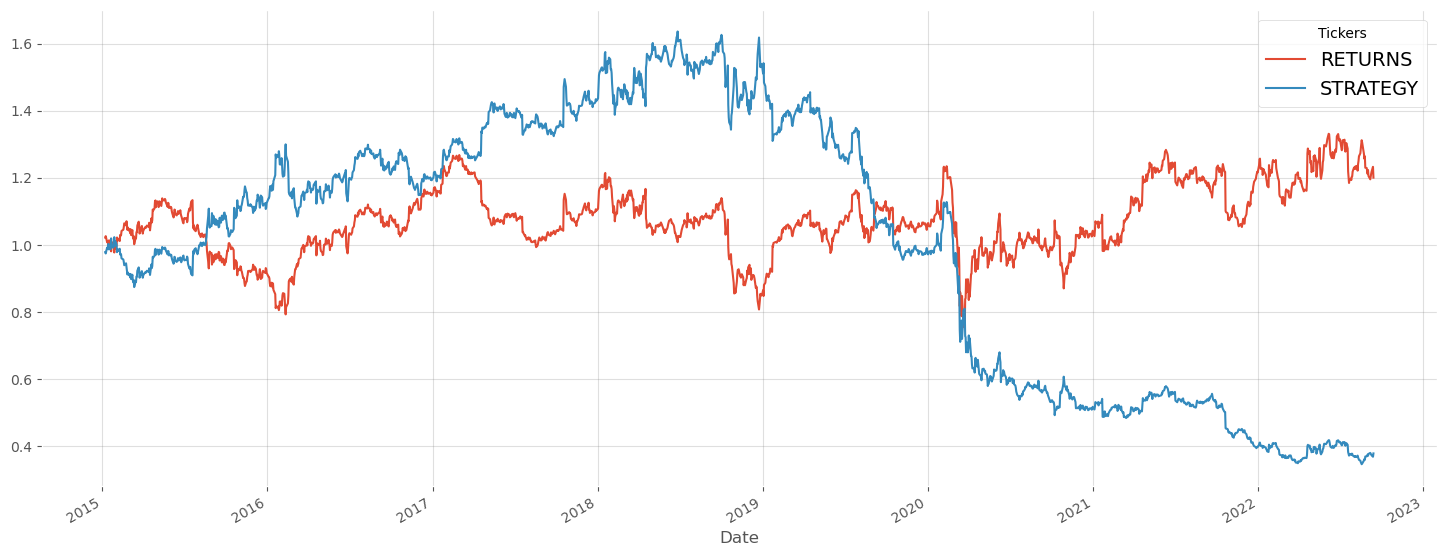

In [25]:
(
    df_ibm
    [["RETURNS", "STRATEGY"]]
    .cumsum()
    .apply(np.exp)
).plot(figsize = [18, 7]
      )

### <font color = red> Question 4</font>. Based on your lines of codes that lead to answer 3 above, please calculate the maximum drawdown and the longest drawdown period.

In [26]:
df_drawdown =\
(
    df_ibm[["STRATEGY"]]
)

df_drawdown

Tickers,STRATEGY
Date,
2015-01-07,NaN
2015-01-08,-0.021502
2015-01-09,-0.004346
2015-01-12,0.016923
2015-01-13,-0.002363
...,...
2022-09-07,-0.007782
2022-09-08,-0.005933
2022-09-09,-0.005589


/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_42181/3831853449.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drawdown["CUMULATIVE_RETURNS"] =\
/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_42181/3831853449.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drawdown["MAX_GROSS_PERFORMANCE"]=\


<Axes: xlabel='Date'>

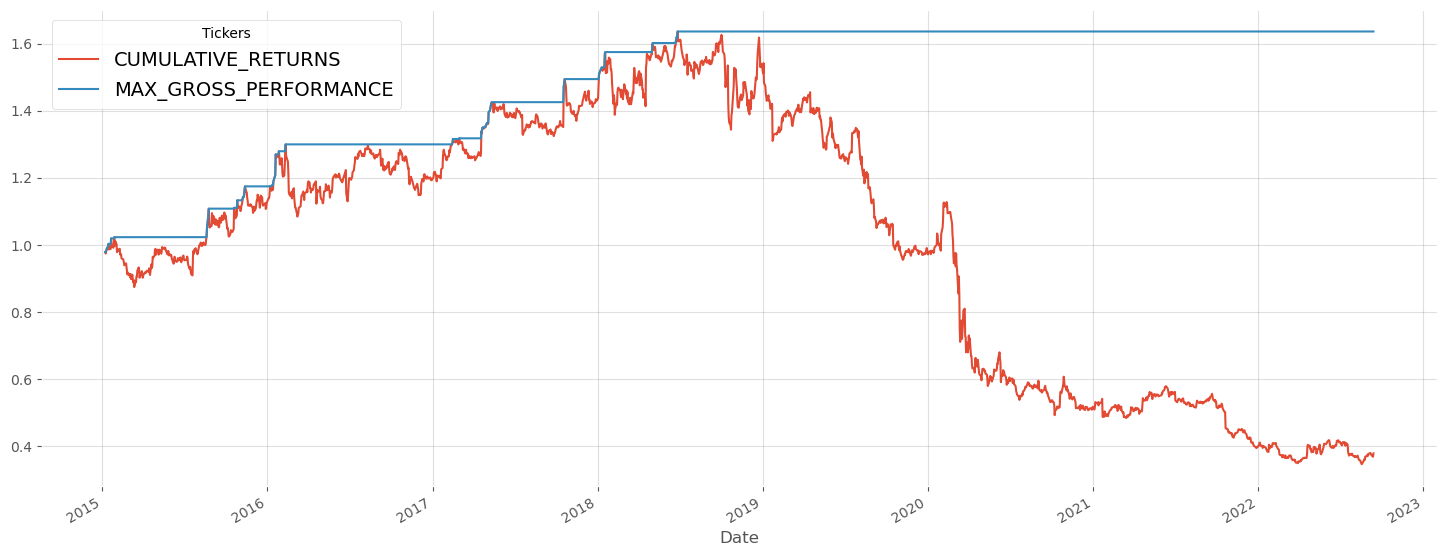

In [28]:
df_drawdown["CUMULATIVE_RETURNS"] =\
(
    df_drawdown
    ["STRATEGY"]
    .cumsum()
    .apply(np.exp)
)

df_drawdown["MAX_GROSS_PERFORMANCE"]=\
(
    df_drawdown
    ["CUMULATIVE_RETURNS"]
    .cummax()
)

(
    df_drawdown
    [["CUMULATIVE_RETURNS", "MAX_GROSS_PERFORMANCE"]]
).plot(figsize = [18, 7]
      )

In [29]:
df_drawdown["DRAWDOWN"] =\
(
    df_drawdown["MAX_GROSS_PERFORMANCE"] - df_drawdown["CUMULATIVE_RETURNS"]
)

max_drawdown = df_drawdown["DRAWDOWN"].max()

# Team, this won't give you what you wished to obtain...

periods =\
(
    df_drawdown["DRAWDOWN"][df_drawdown["DRAWDOWN"] == 0].index[1 :  ].to_pydatetime()
    -
    df_drawdown["DRAWDOWN"][df_drawdown["DRAWDOWN"] == 0].index[  :-1].to_pydatetime()
)

periods.max() # returns datetime.timedelta

/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_42181/778002788.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drawdown["DRAWDOWN"] =\


datetime.timedelta(days=369)

In [30]:
df_drawdown[df_drawdown["DRAWDOWN"] == 0].index

DatetimeIndex(['2015-01-08', '2015-01-12', '2015-01-14', '2015-01-15',
               '2015-01-21', '2015-01-28', '2015-08-20', '2015-08-21',
               '2015-08-24', '2015-08-25', '2015-10-20', '2015-10-27',
               '2015-11-09', '2015-11-11', '2015-11-12', '2015-11-13',
               '2016-01-08', '2016-01-13', '2016-01-15', '2016-01-19',
               '2016-01-20', '2016-01-27', '2016-02-11', '2017-02-14',
               '2017-02-15', '2017-03-01', '2017-04-19', '2017-04-21',
               '2017-04-26', '2017-05-01', '2017-05-03', '2017-05-05',
               '2017-05-08', '2017-05-09', '2017-05-10', '2017-05-11',
               '2017-05-12', '2017-10-18', '2017-10-19', '2017-10-20',
               '2018-01-04', '2018-01-05', '2018-01-08', '2018-01-09',
               '2018-01-10', '2018-01-11', '2018-01-17', '2018-01-18',
               '2018-05-02', '2018-05-03', '2018-06-25', '2018-06-27'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [31]:
current_drawdown_period =\
(
    df_drawdown["DRAWDOWN"].index[-1].to_pydatetime()
    -
    df_drawdown["DRAWDOWN"][df_drawdown["DRAWDOWN"] == 0].index[-1].to_pydatetime()
)

current_drawdown_period # returns timedelta

datetime.timedelta(days=1539)

In [32]:
max_drawdown

1.2901795110669905

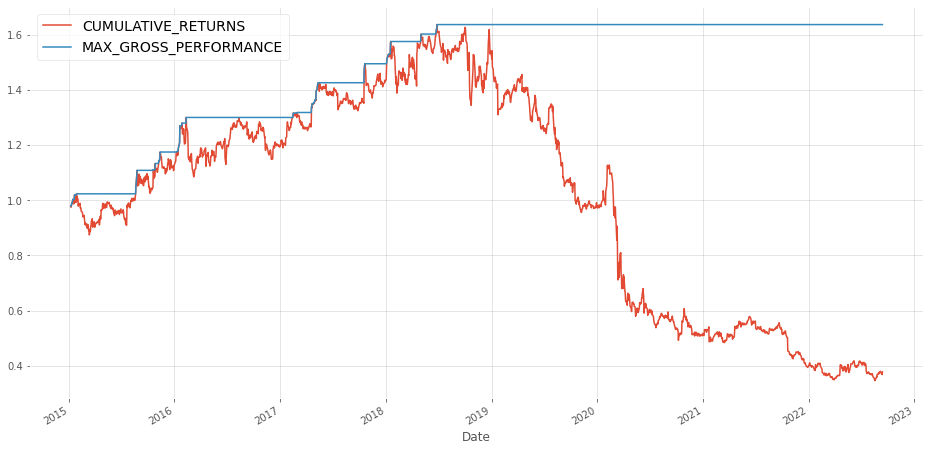

### Please make sure to answer below.

    The maximum drawdown is about __129__ percentage points.
    The longest drawdown period lasts for ___1,539___ days and counting.

### <font color = red> Question 5</font>. Now let’s have a look at the stock price of Walmart (WMT). Please create your strategy based on mean-reversion strategy.

### Here, specifically, please implement a mean-reversion strategy on the basis of a `Simple Moving Average of 41 days` and a `threshold value of 4 for the absolute deviation of the current price` to deviate from the Simple Moving Average to signal a positioning.

In [33]:
%who

ax	 concat_DF_for_practice	 current_drawdown_period	 df	 df_drawdown	 df_ibm	 dt	 end	 ibm	 
max_drawdown	 mpl	 np	 pd	 pdr	 periods	 plt	 start	 walmart	 
yf	 


In [34]:
df_wmt =\
(
    df
    [["WMT"]]
)

# passive following

df_wmt["RETURNS"] =\
(
    np
    .log(df_wmt["WMT"]
         /
         df_wmt["WMT"]
         .shift(1)
        )
)

In [35]:
threshold = 4

df_wmt["SMA_41"] =\
(
    df_wmt
    ["WMT"]
    .rolling(window = 41)
    .mean()
)

df_wmt["distance"] = df_wmt["WMT"] - df_wmt["SMA_41"]

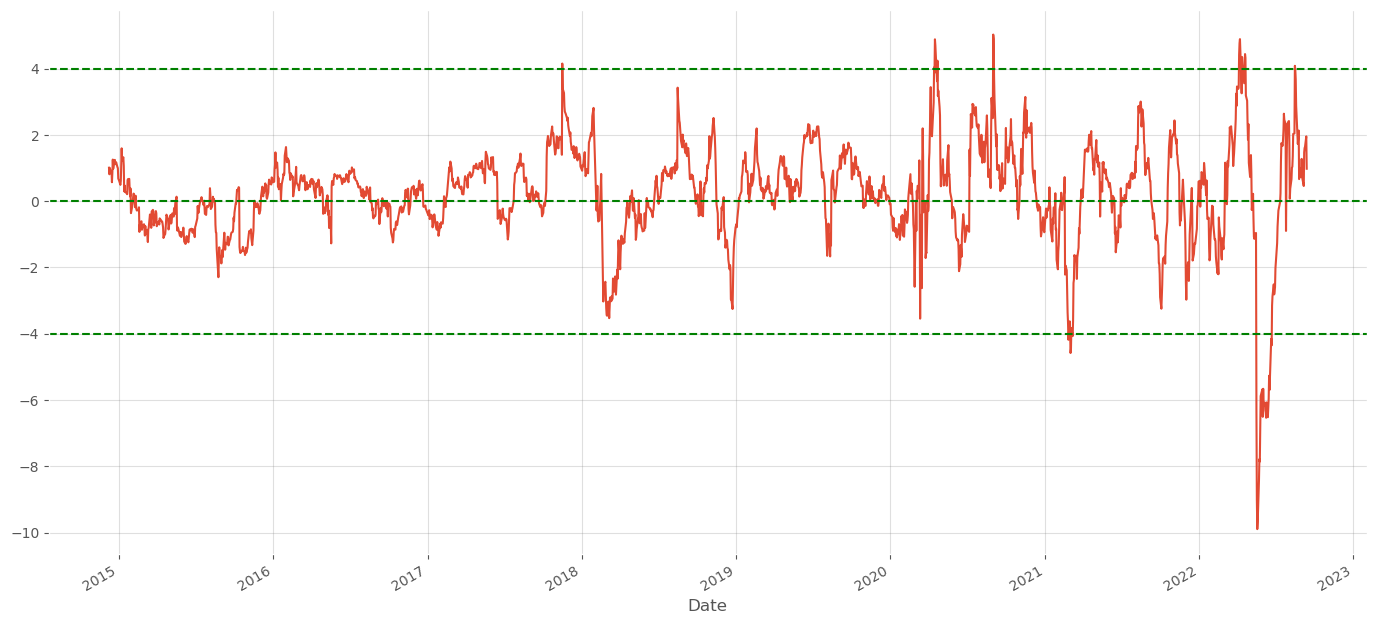

In [36]:
(
    df_wmt
    ["distance"]
    .dropna()
    .plot(figsize = [17, 8]
         )
)

plt.axhline(threshold, 
            color = "green", 
            ls = "--")

plt.axhline(-threshold, 
            color = "green", 
            ls = "--")

plt.axhline(0, 
            color = "green", 
            ls = "--")

### <font color = red> Question 6</font> Now, please plot your buy positions using red dots, and your sell positions using blue dots, as shown below.

In [37]:
# sell signal

df_wmt["positions"] =\
(
    np
    .where(df_wmt["distance"] > threshold,
           -1, np.nan)
)

# buy signal

df_wmt["positions"] =\
(
    np
    .where(df_wmt["distance"] < -threshold,
           1, df_wmt["positions"]
          )
)

# market-neutral

df_wmt["positions"] =\
(           # -                 # + 
    np      # +                 # - 
    .where(df_wmt["distance"] * df_wmt["distance"].shift(1) < 0,
           0, df_wmt["positions"]
          )
)

<Axes: xlabel='Date'>

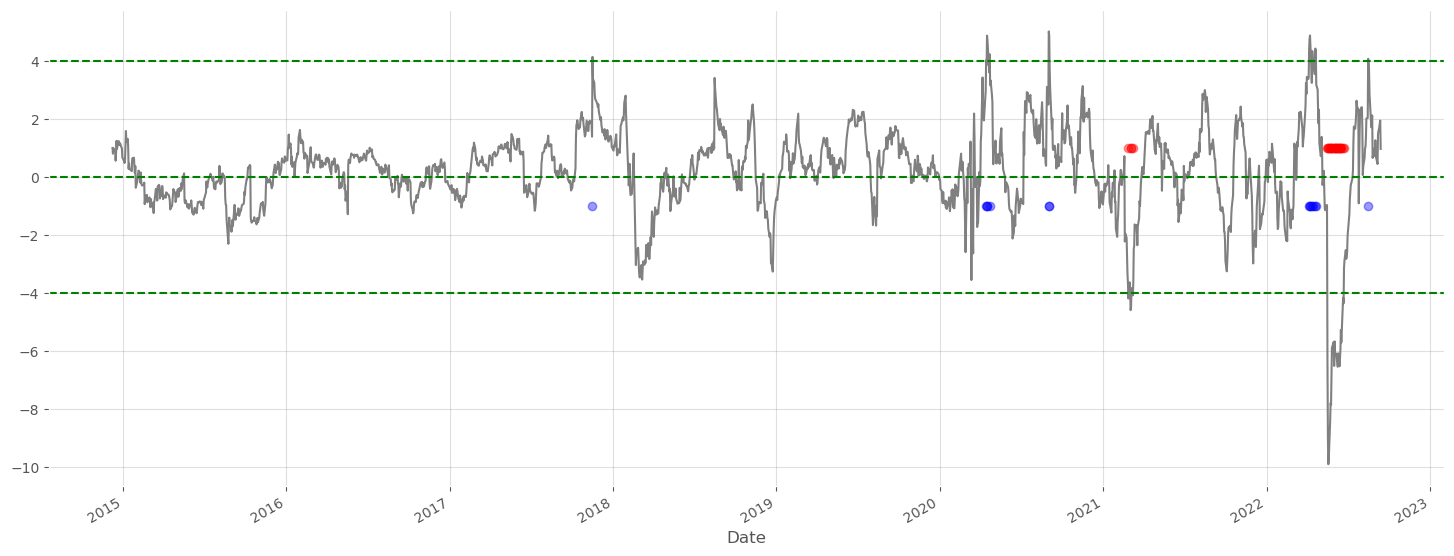

In [39]:
df_wmt["distance"] = df_wmt["WMT"] - df_wmt["SMA_41"]

(
    df_wmt["distance"]
    .dropna()
    .plot(figsize = [18, 7],
          color = "grey")
)

plt.axhline(0, color = "green", ls = "--")
plt.axhline(threshold, color = "green", ls = "--")
plt.axhline(-threshold, color = "green", ls = "--")

(
    df_wmt
    ["positions"]
    .loc[df_wmt["positions"] == 1]
    .plot(style = "o",
          color = "red",
          alpha = 0.40)
)

(
    df_wmt
    ["positions"]
    .loc[df_wmt["positions"] == -1]
    .plot(style = "o",
          color = "blue",
          alpha = 0.40)
)  

In [40]:
(
    df_wmt
    [~df_wmt["positions"]
     .isna()
    ]
    .shape[0]
)

188

### Then, please come up with an answer for the question below.

    Based on mean-reversion strategy, there were _______ trading opportunities found.

### <font color = red> Question 7</font> Please draw the strategy returns as shown below.

<Axes: xlabel='Date'>

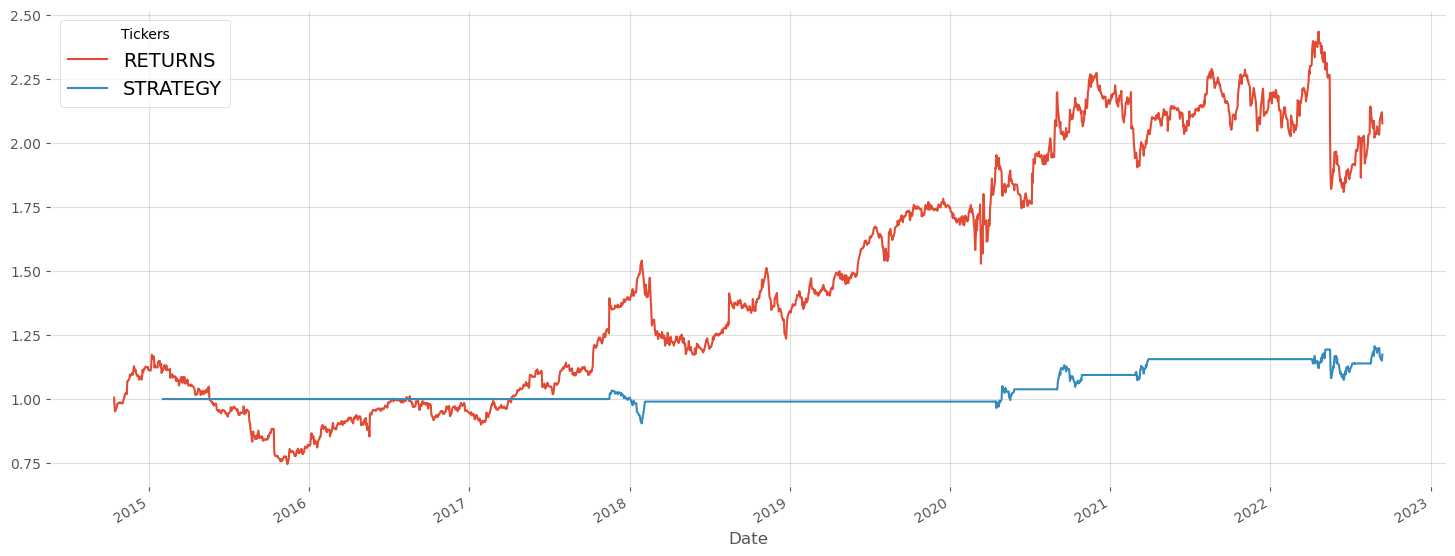

In [41]:
df_wmt["RETURNS"] =\
(
    np
    .log(df_wmt["WMT"]
         /
         df_wmt["WMT"].shift(1)
        )
)

df_wmt["STRATEGY"] =\
(# Chaining vs. Modularization
    df_wmt["positions"]
    .ffill()
    .shift(1)
    *
    df_wmt["RETURNS"]
)

(
    df_wmt
    [["RETURNS", "STRATEGY"]]
    .cumsum()
    .apply(np.exp)
).plot(figsize = [18, 7]
      )

### <font color = red> Question 8</font>. Please calculate the Sharpe Ratio of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a Sharpe ratio of _________ . 

    Mean reversion strategy for WMT leads to a Sharpe ratio of _________ .

In [42]:
sharpe_ibm =\
(
    np.sqrt(252)
    *
    (df_ibm["STRATEGY"].mean()
     /
     df_ibm["STRATEGY"].std()
    )
)

In [43]:
sharpe_wmt =\
(
    np.sqrt(252)
    *
    (df_wmt["STRATEGY"].mean()
     /
     df_wmt["STRATEGY"].std()
    )
)

In [44]:
print(sharpe_ibm);print(sharpe_wmt)

-0.5106443547818229
0.296637380688435


### <font color = red> Question 9</font>. Please calculate the Compound Annual Growth Rate (CAGR) of the strategies for `IBM` and `WMT`, respectively.

    Simple moving strategy for IBM leads to a CAGR of _________ . 

    Mean reversion strategy for WMT leads to a CAGR of _________ .


In [45]:
df_ibm.columns 

Index(['IBM', 'SMA_20', 'SMA_60', 'positions', 'returns', 'RETURNS',
       'STRATEGY'],
      dtype='object', name='Tickers')

In [46]:
df_ibm["CUM"] =\
(
    df_ibm["STRATEGY"]
    .fillna(0)
    .cumsum()
    .apply(np.exp)
)

days_ibm =\
(
    (df_ibm.index[-1] - df_ibm.index[0])
    .days
)

CAGR_ibm =\
(
    (    
        (
        (df_ibm["CUM"][-1]) / (df_ibm["CUM"][0])
        ) 
            ** (365.0 / days_ibm)
    )
    - 1
)

CAGR_ibm

/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_42181/910774510.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df_ibm["CUM"][-1]) / (df_ibm["CUM"][0])


-0.11876771586844015

In [47]:
df_wmt["positions"] =\
(
    df_wmt["positions"]
    .ffill()
)

In [48]:
df_wmt =\
(
    df_wmt
    [~df_wmt["positions"].isna()
     ]
)

In [49]:
%whos

Variable                  Type         Data/Info
------------------------------------------------
CAGR_ibm                  float64      -0.11876771586844015
ax                        Axes         Axes(0.125,0.2;0.775x0.68)
concat_DF_for_practice    DataFrame               Date        Op<...>\n[3988 rows x 8 columns]
current_drawdown_period   timedelta    1539 days, 0:00:00
days_ibm                  int          2806
df                        DataFrame    Tickers            IBM   <...>\n[1994 rows x 2 columns]
df_drawdown               DataFrame    Tickers     STRATEGY  CUM<...>\n[1935 rows x 4 columns]
df_ibm                    DataFrame    Tickers            IBM   <...>\n[1935 rows x 8 columns]
df_wmt                    DataFrame    Tickers           WMT   R<...>\n[1919 rows x 6 columns]
dt                        module       <module 'datetime' from '<...>b/python3.9/datetime.py'>
end                       datetime     2022-09-14 00:00:00
ibm                       DataFrame          

In [50]:
df_wmt["CUM"] =\
(# Again, chaining
    df_wmt
    ["STRATEGY"]
    .fillna(0)
    .cumsum()
    .apply(np.exp)
)

days_wmt =\
(
    (
    df_wmt.index[-1] - df_wmt.index[0] 
    ).days
)

CAGR_wmt =\
(
    (    
        (
        (df_wmt["CUM"][-1]) / (df_wmt["CUM"][0])
        )
        ** (365.0 / days_wmt)
    )
    - 1
)

CAGR_wmt

/var/folders/m5/6qjdcqv55y72ghb4rkssq56m0000gn/T/ipykernel_42181/4054550083.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (df_wmt["CUM"][-1]) / (df_wmt["CUM"][0])


0.02127424299234071

### <font color = red> Question 10</font>. This question is based on the following scenario. After reading it, please respond to the associated sub-questions.

In [54]:
df_alphas =\
(
    pd
    .read_csv("alphas.csv",
              index_col = 0)
)

In [55]:
df_alphas.head(2)

,Alphas A,Alphas B,Alphas C
2019-05-28,100.000000,100.000000,100.000000
2019-05-29,100.562415,101.991696,100.733993


In [56]:
df_returns =\
(
    np
    .log(df_alphas 
         /
         df_alphas.shift(1)
        )
    .dropna()
)

df_returns.head(2)

,Alphas A,Alphas B,Alphas C
2019-05-29,0.005608,0.019721,0.007313
2019-05-30,-0.016633,0.024554,-0.001640


> Scenario: You've been appointed as a Quantitative Researcher in the process-driven investing division of a leading hedge fund. As part of your onboarding challenge, you are handed data (`alphas.csv`) for three experimental trading models, codenamed Alphas A, B, and C. These models, each initiated with a capital of 100K, demonstrate nearly identical Sharpe ratios across a span of 1120 trading days. Intrigued by this uniformity yet aware of the Sharpe ratio's shortcomings, you embark on a journey to dissect the Alphas' performance through a multifaceted quantitative lens.

> 10-1. Sharpe Ratio Diagnostics:

- Given the daily return series for Alphas A, B, and C:

- Derive the annualized Sharpe ratio for each Alpha, with the industry-standard assumption of 252 trading days per annum. In light of these findings, how might you reconsider the perceived risk-adjusted returns of these models?

In [57]:
# Sharpe

sharpe_ratios =\
(
    np.sqrt(252)
    *
    df_returns.mean(axis = 0)
    /
    df_returns.std(axis = 0)
)

sharpe_ratios

Alphas A   -0.155830
Alphas B   -0.165371
Alphas C   -0.160252
dtype: float64

> 10-2. Trajectory of Cumulative Returns:
    
- Visualize and compare the cumulative returns of each Alpha.

In [58]:
cum_returns =\
(
    df_alphas
    /
    df_alphas.iloc[0]
)

cum_returns.head(2)

,Alphas A,Alphas B,Alphas C
2019-05-28,1.000000,1.000000,1.00000
2019-05-29,1.005624,1.019917,1.00734


<Axes: >

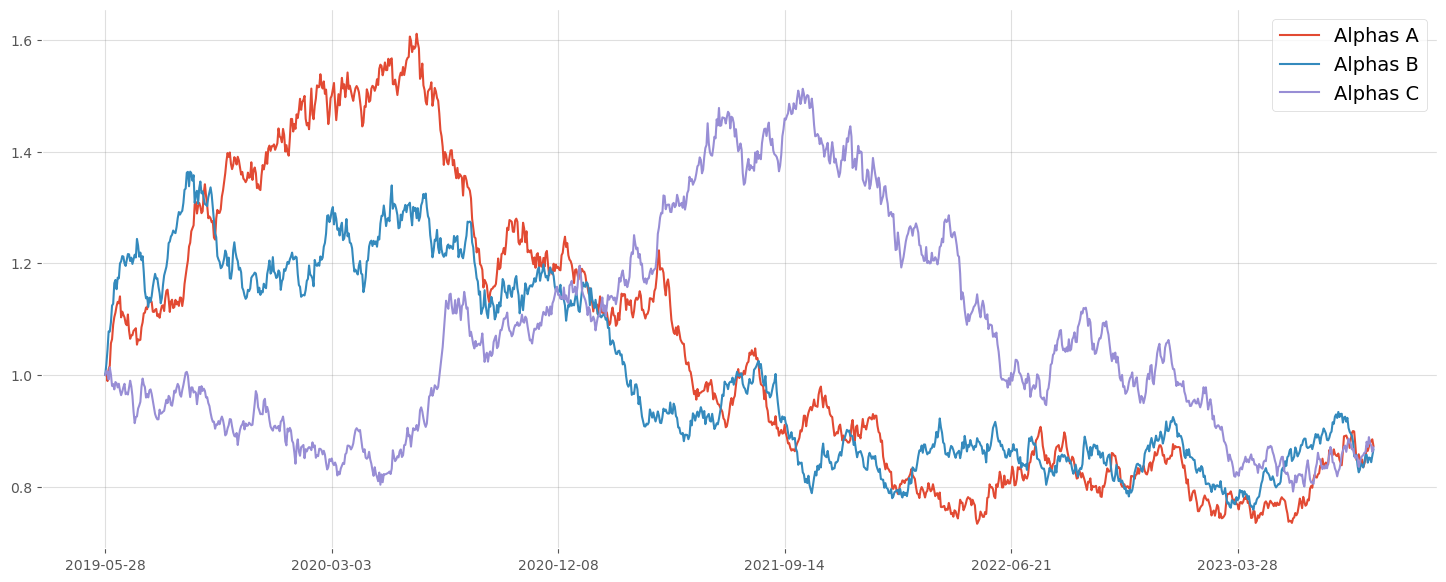

In [61]:
cum_returns.plot(figsize = [18, 7]
                )

> 10-3. Cumulative Returns Over a 1120-Day Horizon:
- Extrapolate the cumulative returns for each Alpha over this period. When evaluating based on the Compound Annual Growth Rate (CAGR), how do these Alphas stack up against one another?

In [62]:
df_CAGR =\
(
    (df_alphas.iloc[-1] / df_alphas.iloc[0])
    **(252/1120)
    - 1
)

df_CAGR

Alphas A   -0.030094
Alphas B   -0.031762
Alphas C   -0.030805
dtype: float64

> 10.4 Delving into Maximum Drawdown (MDD):
- Assess the Maximum Drawdown (MDD) for each model within this time frame. Based on this assessment, which Alpha appears best equipped to withstand market downturns?

In [63]:
df_drawdown =\
(
    cum_returns
    .cummax(axis = 0)
    -
    cum_returns
)

df_drawdown.max()

Alphas A    0.877232
Alphas B    0.605229
Alphas C    0.721001
dtype: float64

In [64]:
# obtain dates where last drawdowns for Alphas A =  0

watermark_A =\
(
    df_drawdown
    [df_drawdown["Alphas A"] == 0]
    .index[-1]
)

# obtain dates where last drawdowns for Alphas B =  0

watermark_B =\
(
    df_drawdown
    [df_drawdown["Alphas B"] == 0]
    .index[-1]
)

# obtain dates where last drawdowns for Alphas C =  0

watermark_C =\
(
    df_drawdown
    [df_drawdown["Alphas C"] == 0]
    .index[-1]
)

# Obtain Current Date 

current_date =\
(
    df_drawdown
    .index[-1]
)

In [65]:
### Report

print(f"""
      Last day without draw downs
      Alpha A: {watermark_A}
      Alpha B: {watermark_B}
      Alpha C: {watermark_C}
      BTW, this is the current date: {current_date}
      """
     )

# YYYY-MM-DD
#   %Y-%m-%d


      Last day without draw downs
      Alpha A: 2020-06-16
      Alpha B: 2019-09-10
      Alpha C: 2021-10-06
      BTW, this is the current date: 2023-09-12
      


> 10.5 Examining Drawdown Duration:
- Analyze the longest drawdown durations for each strategy. Which of the Alphas seems to have the quickest recovery mechanism following a significant drawdown?

In [66]:
# Drawdown duration for Alphas A
duration_A=\
(
    dt.datetime.strptime(current_date, "%Y-%m-%d")
    -
    dt.datetime.strptime(watermark_A, "%Y-%m-%d")
).days

# Drawdown duration for Alphas B
duration_B=\
(
    dt.datetime.strptime(current_date, "%Y-%m-%d")
    -
    dt.datetime.strptime(watermark_B, "%Y-%m-%d")
).days

# Drawdown duration for Alphas C
duration_C=\
(
    dt.datetime.strptime(current_date, "%Y-%m-%d")
    -
    dt.datetime.strptime(watermark_C, "%Y-%m-%d")
).days

In [67]:
### Report

print(f"""
      Drawdown durations for 
      Alphas A: {duration_A}
      Alphas B: {duration_B}
      Alphas C: {duration_C}
      """)


      Drawdown durations for 
      Alphas A: 1183
      Alphas B: 1463
      Alphas C: 706
      


> 10.6 Comprehensive Assessment of Strategy Performance:
- By synthesizing data from metrics such as the Sharpe ratio, cumulative returns trajectory, MDD, and drawdown duration, provide a well-rounded analysis of the three Alphas. Rank and justify your recommendations based on your quantitative insights.

In [68]:
df_alphas.columns

Index(['Alphas A', 'Alphas B', 'Alphas C'], dtype='object')

In [70]:
### In case that you wish to report with tabular data

duration_list =\
    [duration_A,
     duration_B,
     duration_C]

list_dict_metrics = []

for alpha, duration in zip(df_alphas.columns, duration_list):
    (
    list_dict_metrics
        .append(
            {"Alphas": alpha,
             "Sharpe": sharpe_ratios.loc[alpha],
             "CAGR": df_CAGR.loc[alpha],
             "MDD": df_drawdown.max().loc[alpha],
             "Drawdown Duration": duration}
        )
    )

metrics_DF =\
(
    pd
    .DataFrame(
        list_dict_metrics
    )
)

In [71]:
metrics_DF

,Alphas,Sharpe,CAGR,MDD,Drawdown Duration
0,Alphas A,-0.155830,-0.030094,0.877232,1183
1,Alphas B,-0.165371,-0.031762,0.605229,1463
2,Alphas C,-0.160252,-0.030805,0.721001,706


> 10.7 Reflecting on the Sharpe Ratio:
- Given the observed disparities in cumulative returns and MDD among the Alphas, even with similar Sharpe ratios, evaluate the effectiveness of relying solely on the Sharpe ratio. Can you propose additional or refined metrics to differentiate between Alphas with matching Sharpe values but varying performances in other critical areas?

In [72]:
%who

CAGR_ibm	 CAGR_wmt	 alpha	 ax	 concat_DF_for_practice	 cum_returns	 current_date	 current_drawdown_period	 days_ibm	 
days_wmt	 df	 df_CAGR	 df_alphas	 df_drawdown	 df_ibm	 df_returns	 df_wmt	 dt	 
duration	 duration_A	 duration_B	 duration_C	 duration_list	 end	 ibm	 list_dict_metrics	 max_drawdown	 
metrics_DF	 mpl	 np	 pd	 pdr	 periods	 plt	 sharpe_ibm	 sharpe_ratios	 
sharpe_wmt	 start	 threshold	 walmart	 watermark_A	 watermark_B	 watermark_C	 yf	 


In [74]:
### For Eko

sortino_ratios =\
(
    df_returns.mean(axis = 0)
    /
    np.square(
        df_returns * (df_returns < 0)
    )
    .mean(axis = 0)
)

In [76]:
sortino_ratios

Alphas A   -1.542922
Alphas B   -1.676704
Alphas C   -1.571460
dtype: float64

### BONUS: OOP (Object-Oriented Programming)

In [77]:
NVDA =\
(
    yf
    .download("NVDA",
              start = "2021-09-29",
              end = "2024-09-28",
              auto_adjust = True)
)

[*********************100%%**********************]  1 of 1 completed


In [78]:
NVDA

,Open,High,Low,Close,Volume
Date,,,,,
2021-09-29,20.904116,20.980983,20.431925,20.481840,218394000
2021-09-30,20.732409,21.029899,20.652546,20.680498,221009000
2021-10-01,20.714439,20.823251,20.168376,20.706453,240978000
2021-10-04,20.468857,20.506792,19.521484,19.698181,345635000
2021-10-05,19.915810,20.612614,19.819974,20.415951,279282000
...,...,...,...,...,...
2024-09-23,116.550003,116.989998,114.860001,116.260002,206228500
2024-09-24,116.519997,121.800003,115.379997,120.870003,354966800
2024-09-25,122.019997,124.940002,121.610001,123.510002,284692900


### Let's write some customized functions for setting the stage :)

In [79]:
def SMA(array, n):
    return(pd
           .Series(array)
           .rolling(n)
           .mean()
          )

In [80]:
def RSI(array, n):

    Gain = pd.Series(array).diff()
    Loss = Gain.copy()

    Gain[Gain < 0] = 0
    Loss[Loss > 0] = 0

    RS =\
    (
        Gain.ewm(n).mean()
        /
        Loss.abs().ewm(n).mean()
    )

    return 100 - 100 / (1 + RS)

In [81]:
!pip install backtesting


[notice] A new release of pip is available: 23.3.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [82]:
from backtesting import Backtest, Strategy
from backtesting.lib import resample_apply # for weekly rsi calculation

/Users/sroh/miniforge3/envs/rohenv/lib/python3.9/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [83]:
# Let's have some magic :)
# with OOP

class Brain(Strategy):

    D_RSI = 30
    W_RSI = 30

    level = 70

# Initialization Method

    def init(self): # 10, 20, 50, 200
                    # 5, 22, 48, ...
        self.ma10 = self.I(SMA, self.data.Close, 10)
        self.ma20 = self.I(SMA, self.data.Close, 20)
        self.ma50 = self.I(SMA, self.data.Close, 50)
        self.ma200 = self.I(SMA, self.data.Close, 200)

        self.daily_rsi = self.I(RSI, self.data.Close, self.D_RSI)
        self.weekly_rsi = resample_apply("W-Fri", RSI, self.data.Close, self.W_RSI)

    def next(self):
        PRICE = self.data.Close[-1]
        # let's set series of "IF" statements to check conditions for executing a buying order

        if (not self.position and
            self.daily_rsi[-1] > self.level and
            self.weekly_rsi[-1] > self.level and
            self.weekly_rsi[-1] > self.daily_rsi[-1] and
            
            # team, once again, make sure that our SMAs are in bullish alignment
            self.ma10[-1] > self.ma20[-1] > self.ma50[-1] > self.ma200[-1] and
            PRICE > self.ma10[-1] 
           ):

            self.buy(sl = 0.95 * PRICE) # stop-loss

        elif PRICE < 0.97 * self.ma10[-1]:

            self.position.close()

In [84]:
backtest=\
    Backtest(NVDA,
             Brain,
             commission = 0.0015)

In [85]:
backtest\
    .optimize(D_RSI = range(10, 35, 5),
              W_RSI = range(10, 35, 5),
              level = range(30, 70, 10)
             )

/Users/sroh/miniforge3/envs/rohenv/lib/python3.9/site-packages/backtesting/backtesting.py:1375: UserWarning: For multiprocessing support in `Backtest.optimize()` set multiprocessing start method to 'fork'.
  warnings.warn("For multiprocessing support in `Backtest.optimize()` "


  0%|          | 0/10 [00:00<?, ?it/s]

Start                     2021-09-29 00:00:00
End                       2024-09-27 00:00:00
Duration                   1094 days 00:00:00
Exposure Time [%]                   28.249337
Equity Final [$]                 33729.432537
Equity Peak [$]                  37726.732763
Return [%]                         237.294325
Buy & Hold Return [%]              492.720189
Return (Ann.) [%]                   50.130822
Volatility (Ann.) [%]               40.224563
Sharpe Ratio                         1.246274
Sortino Ratio                        4.038864
Calmar Ratio                          2.35573
Max. Drawdown [%]                  -21.280377
Avg. Drawdown [%]                   -4.687453
Max. Drawdown Duration      190 days 00:00:00
Avg. Drawdown Duration       21 days 00:00:00
# Trades                                    6
Win Rate [%]                        66.666667
Best Trade [%]                      75.702928
Worst Trade [%]                     -7.306579
Avg. Trade [%]                    

In [86]:
backtest\
    .plot()

/Users/sroh/miniforge3/envs/rohenv/lib/python3.9/site-packages/backtesting/_plotting.py:455: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df2 = (df.assign(_width=1).set_index('datetime')


Row(id='1672', ...)

### <font color="green">"Thank you for putting your efforts into the exercise problem sets 💯"</font>